# Exercise 3

---

Juan Provencio

Lea Neumann

Anna Bütfering

---

## Import Packages

Questions: 
encoder as forward pass
decoder as backward pass -> still an explicit forward function??

Rotation how and where ?


In [111]:
# Importing relevant packages & function: 

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

import random
import matplotlib.pyplot as plt
import numpy as np

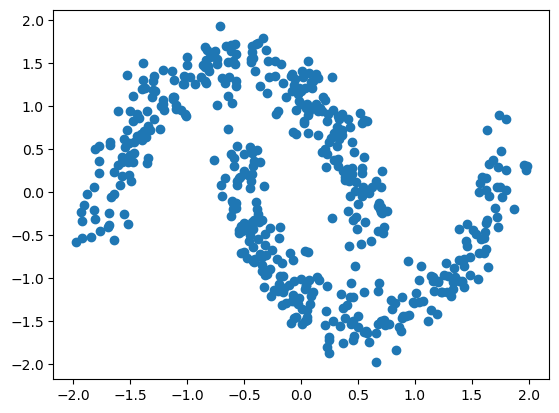

In [126]:
# generate the two moons dataset:
X, y = make_moons(n_samples=10000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = torch.tensor(X_train, dtype= torch.float32) #.clone().detach().requires_grad_(True)
#X_test.clone().detach().requires_grad_(True)
#X_test = scaler.transform(X_test)


_ = plt.scatter(X_train[:500, 0], X_train[:500, 1]) 


## Task 1: Invertible Neural Networks

In [162]:
class RealNVP(nn.Module):
    def __init__(self, input_size=2, hidden_size=1000, blocks=2):
        super(RealNVP, self).__init__()
        
        self.blocks = blocks
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.midD = int(1000/2) # midD: 'middle dimension' calculated by taking half of data dimension (assumed to be 1000 by default)

        # for one block, we need two nested networks: s and t:
        self.nested_network = nn.Sequential(
            nn.Linear(self.input_size, hidden_size), #hidden layer 1
            nn.ReLU(), 
            nn.Linear(hidden_size, hidden_size), # hidden layer 2
            nn.ReLU(),
            nn.Linear(hidden_size, self.input_size) #output layer
            )
        
        # Learnable scaling parameters for outputs of S (initial values are random variables)
        self.s_scale = nn.Parameter(torch.randn(blocks))
        self.mean = nn.Parameter([0.0])
        self.var = nn.Parameter([1.0])
        
    def encode(self, X): #Forward pass through network
        #X_nonrot = X.clone()

        #Adjust data_dim:
        self.midD = int(X.shape[0]/2)

        rots = []
        s_values = []
        for _block in range(self.blocks):
            if _block != (self.blocks - 1):
                # Make a random orthonormal matrix:
                A = torch.randn(self.input_size, self.input_size)
                Q, _ = torch.linalg.qr(A)
                X_rot = X @ Q.T
                rots.append(Q)
            else: 
                X_rot = X # for last block, no rotation
                #print("Last block: No rotation applied.")

            # Split input data into two halves:
            x1, x2 = X_rot[:self.midD], X_rot[self.midD:] # x1 consists of first half, x2 of second half of the data 

            # Skip transformation for first half:
            y1 = x1 

            # Pass x1 through nested network to get s and t:
            t = self.nested_network(x1)
            s_log = self.s_scale * self.nested_network(x1)
            s = torch.exp(torch.tanh(s_log))
            # Compute transformed output for second half:
            y2 = s * x2 + t 

            # Concatenate both halves to get final output: 
            X = torch.cat([y1, y2], dim=0)
            s_values.append(s_log)

        rots_invert = rots[::-1] # reverse the order of the rotation matrices for use in decoding
        encoded = X
        return encoded, torch.cat(s_values, dim=0), rots_invert
    
    def decode(self, Y, rots_invert=None): # backward pass through network
        #Y_nonrot = Y.clone()
        #Adjust data_dim: this should already have been done by the encoder function, just in case
        self.midD = int(Y.shape[0]/2)

        for _block in range(self.blocks):
        
            if _block != (self.blocks - 1):
                # Make a random orthonormal matrix:
                #A = torch.randn(self.input_size, self.input_size)
                #Q, _ = torch.linalg.qr(A)
                Q = rots_invert[_block]
                Y_rot = Y @ Q
            else: 
                Y_rot = Y # for last block, no rotation
                #print("Last block: No rotation applied.")

            # Split input data into two halves:
            y1, y2 = Y_rot[:self.midD], Y_rot[self.midD:] # y1 consists of first half, y2 of second half of the data 

            # Skip transformation for first half:
            x1 = y1 

            # Pass x1 through nested network to get s and t:
            t = self.nested_network(x1)
            s_log = self.s_scale * self.nested_network(x1)
            s = torch.exp(torch.tanh(s_log))
            # Compute transformed output for second half:
            x2 = (y2 - t)/s 

            # Concatenate both halves to get final output: 
            Y = torch.cat([x1, x2], dim=0)
            # Store values for computation of log-det-Jacobian:
        
        decoded = Y
        return decoded
    
    def forward(self, X):
        encoded, s_vals = self.encode(X)
        return encoded, s_vals
    
    def backward(self, Y):
        decoded = self.decode(Y)
        return decoded  

In [158]:
def lossNLL(model, s_vals): # s values are computated as log scaling factors from each block
    log_det_J = torch.sum(s_vals)
    return log_det_J
    

def train_inn(model, X_train, num_epochs=100, batch_size=32, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    #print(model.parameters)
    # criterion is the negative log-likelihood loss as calculated below... 

    indices = list(range(len(X_train)))
    # train the model
    for epoch in range(num_epochs):
        for i in range(0, len(X_train), batch_size):
            # get a random batch of data
            random.shuffle(indices)
            batch = X_train[indices[i:i+batch_size]].clone().detach().requires_grad_(True)
            # forward pass
            encoded, s_vals, rots = model.encode(batch)
            output = model.decode(encoded, rots)
            loss = lossNLL(model, s_vals)
            # backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
        
        # print the loss every 10 epochs
        if (epoch+1) % 5 == 0:
           print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")
           print(model.s_scale[0], model.s_scale[1])
    return model

    


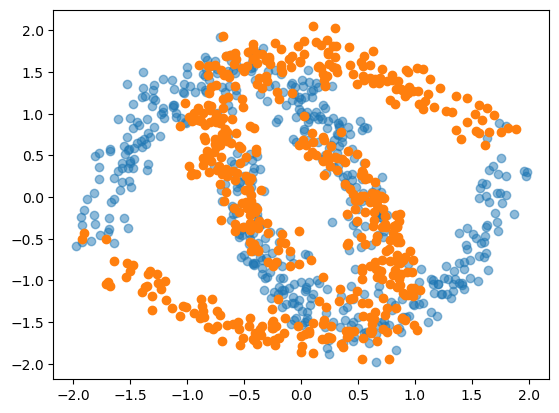

In [161]:
test = RealNVP()

#Make sure that data set has right dtype:
#X_train = torch.tensor(X_train, dtype=torch.float32)
X_train = X_train.clone().detach().requires_grad_(True)

test = train_inn(test,X_train, num_epochs=2, batch_size=500, lr=0.001)

encoded, s_vals, rots = test.encode(X_train)
decoded = test.decode(encoded, rots)
plt.scatter(X_train[:500, 0].detach().numpy(), X_train[:500, 1].detach().numpy(), alpha=0.5)
plt.scatter(encoded[:500, 0].detach().numpy(), encoded[:500, 1].detach().numpy())
